<a href="https://colab.research.google.com/github/gabriellbragaa/Computer_Vision_Projs/blob/main/Lab_08_resolu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB_08: crie e treine um autoencoder que recebe
uma imagem do dataset MNIST e produz uma imagem colorida com o seu respectivo
número em vermelho (se for par) ou em azul (se for ímpar).

## 1. Carregar e preparar os dados
Carregar os datasets MNIST de treinamento e teste.

In [24]:
import numpy as np
import keras

# Carregar os dados e dividi-los entre conjuntos de treinamento e teste
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Escalonar imagens para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Adicionar uma dimensão de canal (para tons de cinza)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print(x_train.shape[0], "amostras de treinamento")
print(x_test.shape[0], "amostras de teste")

x_train shape: (60000, 28, 28, 1)
60000 amostras de treinamento
10000 amostras de teste


In [25]:
import numpy as np

def colorize_mnist(images, labels):
    """
    Coloriza imagens MNIST com base na paridade de seus rótulos.
    Dígitos pares são coloridos de vermelho, dígitos ímpares são coloridos de azul.

    Args:
        images (np.ndarray): Um array numpy de forma (n_samples, 28, 28, 1)
                             contendo imagens MNIST em tons de cinza.
        labels (np.ndarray): Um array numpy de forma (n_samples,)
                             contendo os rótulos inteiros para as imagens.

    Returns:
        np.ndarray: Um array numpy de forma (n_samples, 28, 28, 3)
                    contendo as imagens coloridas.
    """
    colored_images = np.zeros((images.shape[0], 28, 28, 3), dtype=np.float32)

    for i in range(images.shape[0]):
        # Se o rótulo for par (0, 2, 4, 6, 8), colorir de vermelho
        if labels[i] % 2 == 0:
            colored_images[i, :, :, 0] = images[i, :, :, 0] # Canal Vermelho
            # Canais Verde e Azul permanecem 0
        # Se o rótulo for ímpar (1, 3, 5, 7, 9), colorir de azul
        else:
            colored_images[i, :, :, 2] = images[i, :, :, 0] # Canal Azul
            # Canais Vermelho e Verde permanecem 0

    return colored_images

# Gerar imagens coloridas de treinamento e teste
x_train_colored = colorize_mnist(x_train, y_train)
x_test_colored = colorize_mnist(x_test, y_test)

print("x_train_colored shape:", x_train_colored.shape)
print("x_test_colored shape:", x_test_colored.shape)

x_train_colored shape: (60000, 28, 28, 3)
x_test_colored shape: (10000, 28, 28, 3)


In [26]:
# Compilar o autoencoder
# Usando erro quadrático médio como a função de perda e otimizador Adam
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
# Treinar o autoencoder
# Usar as imagens originais em tons de cinza como entrada e as imagens coloridas como saída alvo
autoencoder.fit(x_train, x_train_colored,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test, x_test_colored))

Epoch 1/5
368/469 ━━━━━━━━━━━━━━━━━━━━ 30s 297ms/step - accuracy: 0.6404 - loss: 0.0373

## 6. Avaliar o autoencoder
Avaliar o desempenho do autoencoder treinado na colorização das imagens MNIST de teste.

In [22]:
# Avaliar o autoencoder nos dados de teste
loss = autoencoder.evaluate(x_test, x_test_colored, verbose=0)
print(f"Perda de Teste (Erro Quadrático Médio): {loss[0]:.4f}")

Test Loss (Mean Squared Error): 0.0380


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


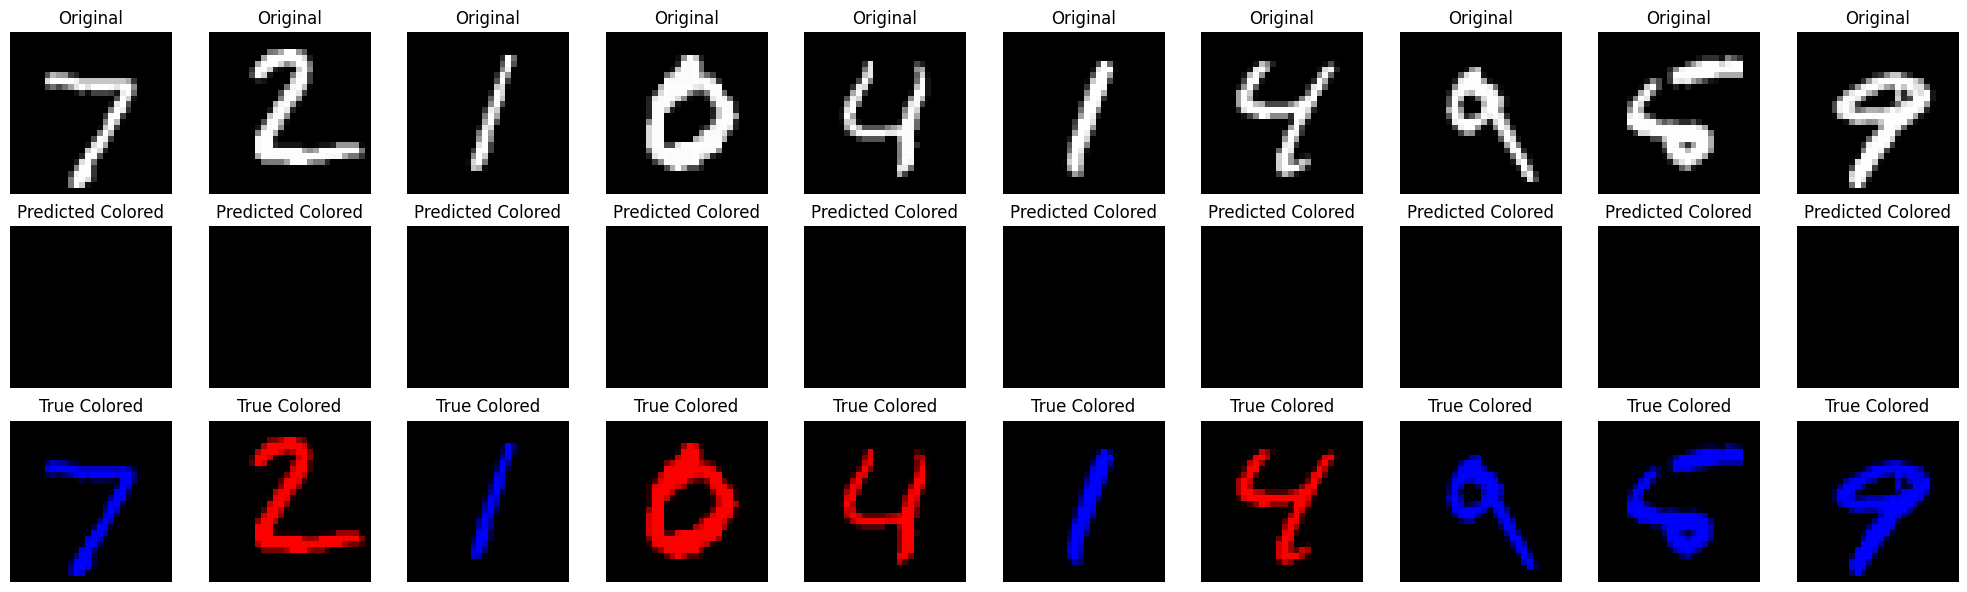

In [23]:
import matplotlib.pyplot as plt

# Prever imagens coloridas para o conjunto de teste
predicted_colored_images = autoencoder.predict(x_test)

# Exibir alguns exemplos
n = 10  # Número de exemplos para exibir
plt.figure(figsize=(20, 6))

for i in range(n):
    # Imagem original em tons de cinza
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Imagem colorida prevista pelo Autoencoder
    ax = plt.subplot(3, n, i + n + 1)
    # Limitar os valores ao intervalo [0, 1] antes de exibir
    plt.imshow(np.clip(predicted_colored_images[i], 0.0, 1.0))
    plt.title("Colorida Prevista")
    plt.axis('off')

    # Imagem colorida verdadeira (Ground Truth)
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(x_test_colored[i])
    plt.title("Colorida Verdadeira")
    plt.axis('off')

plt.tight_layout()
plt.show()